# 🔷 10. Hessian Matrix — Interactive Visualization

**MLVerse-Math Educational Repository**

---

## 📌 Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the geometric meaning of the Hessian matrix as a description of local curvature.
2. **Compute** second-order partial derivatives and assemble them into the Hessian matrix.
3. **Interpret** eigenvalues of the Hessian to classify critical points (convex, concave, saddle).
4. **Apply** the Hessian in Newton's method for second-order optimization.
5. **Connect** Hessian analysis to neural network loss landscapes and modern AI.

---

## 🧠 Intuition

The **gradient** tells us the direction of steepest ascent.
The **Hessian** tells us *how* the gradient changes — it describes the **curvature** of the landscape.

If you're at the bottom of a valley, the Hessian helps you know whether you're in a
shallow puddle or a deep canyon — and whether the walls curve up in every direction.

---

## 🌍 Real-World Motivation

- **Optimization**: Newton's method uses the Hessian to converge faster than gradient descent.
- **Neural Networks**: The Hessian of the loss landscape reveals training stability and generalization.
- **Computer Vision**: Hessian-based corner detection identifies salient image features.
- **Robotics**: Trajectory optimization uses curvature to find smooth, efficient paths.

---

## 🤖 AI Relevance

In deep learning, the **Hessian of the loss function** determines:
- Whether training converges to a minimum or gets stuck in a saddle.
- The **flatness** of minima, which correlates with better generalization.
- The **condition number**, which affects optimization speed.

---

## 📐 Mathematical Definition

For a function $f: \mathbb{R}^n \to \mathbb{R}$, the **Hessian matrix** $H$ is:

$$\
H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}\
$$

For $n=2$:

$$\
H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}\
$$

The Hessian is **symmetric** (by Clairaut's theorem on continuous second derivatives):

$$\
\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}\
$$

In [3]:
# ============================================================
# Imports and Setup
# ============================================================

import numpy as np
import sympy as sp
from scipy import optimize, linalg
import matplotlib.pyplot as plt
from matplotlib import cm, colors, animation
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown, Button, HBox, VBox, Output
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Enable interactive matplotlib backend


# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Print versions for reproducibility
print("NumPy:", np.__version__)
print("SymPy:", sp.__version__)
print("SciPy:", __import__('scipy').__version__)
print("Matplotlib:", plt.matplotlib.__version__)
# print("Plotly:", go.__version__)
print("Pandas:", pd.__version__)
print("\n✅ All libraries imported successfully!")

NumPy: 2.4.6
SymPy: 1.14.0
SciPy: 1.17.1
Matplotlib: 3.10.9
Pandas: 3.0.3

✅ All libraries imported successfully!


---

# 1. Surface Curvature Visualization

## 🎯 Objective

Visualize multiple canonical surfaces to build intuition about local curvature.

## 📖 Introduction

Different surfaces exhibit different curvature patterns:

| Surface | Equation | Curvature Type |
|---------|----------|----------------|
| **Paraboloid** | $z = x^2 + y^2$ | Positive everywhere (convex) |
| **Saddle** | $z = x^2 - y^2$ | Mixed (saddle point at origin) |
| **Gaussian** | $z = e^{-(x^2+y^2)}$ | Varies (peak then flat) |
| **Cone** | $z = \sqrt{x^2 + y^2}$ | Non-differentiable at tip |
| **Ripple** | $z = \sin(\sqrt{x^2+y^2})$ | Oscillating curvature |

## 🧠 Intuition

The **Hessian** at a point captures the **second-order behavior** of the surface.
By examining these surfaces, we can see how curvature manifests visually:
- **Convex**: curves upward in all directions (like a bowl).
- **Concave**: curves downward in all directions (like an inverted bowl).
- **Saddle**: curves up in some directions, down in others.

## 🤖 AI Relevance

Neural network loss landscapes can resemble any of these surfaces.
Understanding curvature helps diagnose why optimization succeeds or fails.

In [4]:
# ============================================================
# Section 1: Surface Curvature Visualization
# ============================================================

def create_surface_grid(x_range=(-3, 3), y_range=(-3, 3), n_points=100):
    """Create a uniform grid for surface plotting."""
    x = np.linspace(x_range[0], x_range[1], n_points)
    y = np.linspace(y_range[0], y_range[1], n_points)
    X, Y = np.meshgrid(x, y)
    return X, Y

def paraboloid(X, Y):
    """Convex paraboloid: z = x^2 + y^2"""
    return X**2 + Y**2

def saddle_surface(X, Y):
    """Saddle surface: z = x^2 - y^2"""
    return X**2 - Y**2

def gaussian_surface(X, Y, sigma=1.0):
    """Gaussian surface: z = exp(-(x^2+y^2)/(2*sigma^2))"""
    return np.exp(-(X**2 + Y**2) / (2 * sigma**2))

def cone_surface(X, Y):
    """Cone surface: z = sqrt(x^2 + y^2)"""
    return np.sqrt(X**2 + Y**2)

def ripple_surface(X, Y):
    """Ripple surface: z = sin(sqrt(x^2+y^2))"""
    R = np.sqrt(X**2 + Y**2)
    R = np.where(R == 0, 1e-10, R)
    return np.sin(R)

SURFACES = {
    'Paraboloid': paraboloid,
    'Saddle': saddle_surface,
    'Gaussian': gaussian_surface,
    'Cone': cone_surface,
    'Ripple': ripple_surface
}

def plot_surface_interactive(surface_name='Paraboloid', colormap='Viridis', n_points=100):
    X, Y = create_surface_grid(n_points=n_points)
    Z = SURFACES[surface_name](X, Y)
    
    fig = go.Figure(data=[go.Surface(
        x=X, y=Y, z=Z,
        colorscale=colormap,
        colorbar=dict(title='z value'),
        hovertemplate='x: %{x:.2f}<br>y: %{y:.2f}<br>z: %{z:.2f}<extra></extra>'
    )])
    
    fig.update_layout(
        title=dict(
            text=f'<b>{surface_name} Surface</b><br><sub>Interactive 3D Visualization</sub>',
            x=0.5, font=dict(size=18)
        ),
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectratio=dict(x=1, y=1, z=0.5),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.0))
        ),
        width=800, height=700,
        margin=dict(l=0, r=0, b=0, t=50)
    )
    
    fig.show()

interact(
    plot_surface_interactive,
    surface_name=Dropdown(
        options=list(SURFACES.keys()),
        value='Paraboloid',
        description='Surface:'
    ),
    colormap=Dropdown(
        options=['Viridis', 'Plasma', 'Inferno', 'Cividis', 'Coolwarm', 'RdBu'],
        value='Viridis',
        description='Colormap:'
    ),
    n_points=IntSlider(min=50, max=200, step=25, value=100, description='Grid:')
)

print("\n🎮 Use the dropdowns to explore different surfaces!")
print("💡 Try rotating and zooming the 3D plot.")

interactive(children=(Dropdown(description='Surface:', options=('Paraboloid', 'Saddle', 'Gaussian', 'Cone', 'R…


🎮 Use the dropdowns to explore different surfaces!
💡 Try rotating and zooming the 3D plot.


---

# 2. Second Derivative Explorer

## 🎯 Objective

Visualize the three second-order partial derivatives that form the Hessian matrix.

## 📖 Mathematical Background

For a function $f(x, y)$, the second-order partial derivatives are:

$$\
f_{xx} = \frac{\partial^2 f}{\partial x^2}, \quad
f_{yy} = \frac{\partial^2 f}{\partial y^2}, \quad
f_{xy} = \frac{\partial^2 f}{\partial x \partial y} = f_{yx}\
$$

## 🧠 Intuition

- **$f_{xx}$**: How does the slope in the $x$-direction change as we move in $x$?
- **$f_{yy}$**: How does the slope in the $y$-direction change as we move in $y$?
- **$f_{xy}$**: How does the slope in the $x$-direction change as we move in $y$? (cross-curvature)

These three values completely determine the local curvature at any point.

## 🤖 AI Relevance

In neural networks, the diagonal entries ($f_{xx}$, $f_{yy}$) relate to the
**curvature along each parameter dimension**, while the off-diagonal entries
($f_{xy}$) capture **parameter interactions** — how changing one weight affects
the gradient with respect to another.

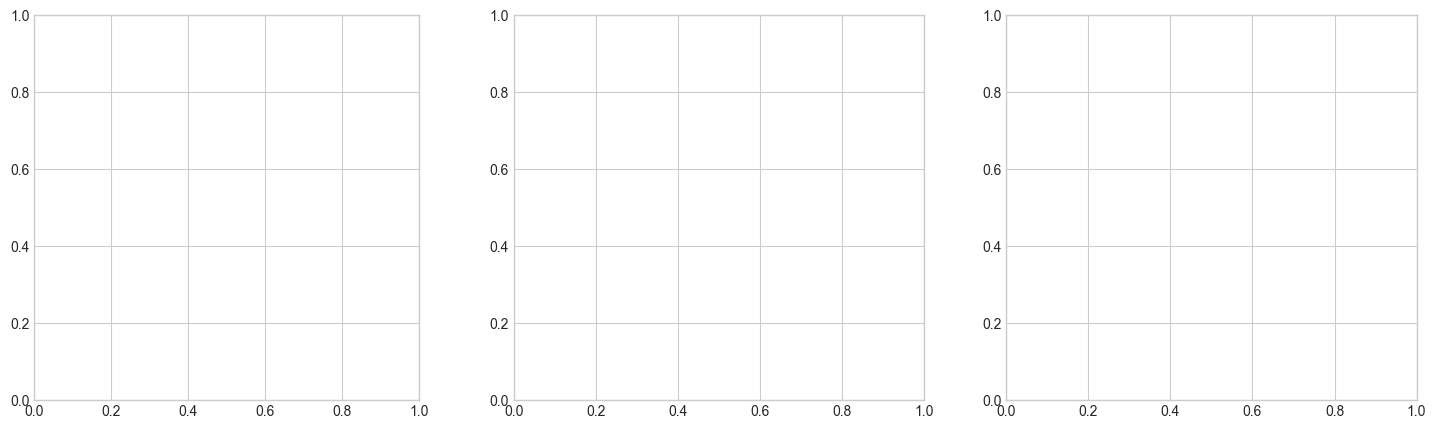

interactive(children=(Dropdown(description='Function:', options={'Paraboloid': 'x**2 + y**2', 'Saddle': 'x**2 …


🎮 Select a function and move the point to see how second derivatives change!


In [5]:
# ============================================================
# Section 2: Second Derivative Explorer
# ============================================================

def compute_second_derivatives_symbolic(func_str, x_val=0, y_val=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_xx_val = float(f_xx.subs([(x, x_val), (y, y_val)]))
    f_yy_val = float(f_yy.subs([(x, x_val), (y, y_val)]))
    f_xy_val = float(f_xy.subs([(x, x_val), (y, y_val)]))
    return {
        'f_xx': f_xx, 'f_yy': f_yy, 'f_xy': f_xy,
        'f_xx_val': f_xx_val, 'f_yy_val': f_yy_val, 'f_xy_val': f_xy_val,
        'hessian': np.array([[f_xx_val, f_xy_val], [f_xy_val, f_yy_val]])
    }

def plot_second_derivatives(func_str='x**2 + y**2', x_point=0.0, y_point=0.0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_xx_func = sp.lambdify((x, y), f_xx, 'numpy')
    f_yy_func = sp.lambdify((x, y), f_yy, 'numpy')
    f_xy_func = sp.lambdify((x, y), f_xy, 'numpy')
    X, Y = create_surface_grid(n_points=80)
    Z_xx = f_xx_func(X, Y)
    Z_yy = f_yy_func(X, Y)
    Z_xy = f_xy_func(X, Y)
    Z_xx = np.array(Z_xx)
    Z_yy = np.array(Z_yy)
    Z_xy = np.array(Z_xy)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = [
        f'$f_{{xx}} = {sp.latex(f_xx)}$',
        f'$f_{{yy}} = {sp.latex(f_yy)}$',
        f'$f_{{xy}} = {sp.latex(f_xy)}$'
    ]
    data_list = [Z_xx, Z_yy, Z_xy]
    for ax, data, title in zip(axes, data_list, titles):
        im = ax.imshow(data, extent=[-3, 3, -3, 3], origin='lower',
                       cmap='RdBu_r', aspect='equal')
        ax.plot(x_point, y_point, 'ko', markersize=12, markeredgecolor='white',
                markeredgewidth=2, label='Selected point')
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(loc='upper right')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.suptitle(f'Second-Order Partial Derivatives\n$f(x,y) = {sp.latex(f)}$ at $({x_point:.2f}, {y_point:.2f})$',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    f_xx_val = float(f_xx.subs([(x, x_point), (y, y_point)]))
    f_yy_val = float(f_yy.subs([(x, x_point), (y, y_point)]))
    f_xy_val = float(f_xy.subs([(x, x_point), (y, y_point)]))
    print(f"\n📊 Values at ({x_point:.2f}, {y_point:.2f}):")
    print(f"   f_xx = {f_xx_val:.4f}")
    print(f"   f_yy = {f_yy_val:.4f}")
    print(f"   f_xy = {f_xy_val:.4f}")
    print(f"\n📐 Hessian at this point:")
    H = np.array([[f_xx_val, f_xy_val], [f_xy_val, f_yy_val]])
    print(H)

function_options = {
    'Paraboloid': 'x**2 + y**2',
    'Saddle': 'x**2 - y**2',
    'Gaussian': 'exp(-(x**2 + y**2)/2)',
    'Cubic': 'x**3 + y**3 - 3*x*y',
    'Rosenbrock': '(1-x)**2 + 100*(y-x**2)**2'
}

interact(
    plot_second_derivatives,
    func_str=Dropdown(options=function_options, value='x**2 + y**2', description='Function:'),
    x_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='x:'),
    y_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='y:')
)

print("\n🎮 Select a function and move the point to see how second derivatives change!")

---

# 3. Hessian Matrix Construction Animation

## 🎯 Objective

Animate the step-by-step construction of the Hessian matrix to emphasize
its symmetry and the meaning of each entry.

## 📖 Mathematical Background

The Hessian is built from second-order partial derivatives:

$$\
H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}\
$$

## 🧠 Key Insight: Symmetry

By **Clairaut's Theorem**, if the second partial derivatives are continuous, then:

$$\
\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}\
$$

This means the Hessian is always a **symmetric matrix**, which guarantees
real eigenvalues — a crucial property for optimization analysis.

## 🤖 AI Relevance

The symmetry of the Hessian means we only need to compute $n(n+1)/2$ entries
instead of $n^2$, significantly reducing computational cost in high-dimensional
neural network optimization.

In [6]:
# ============================================================
# Section 3: Hessian Matrix Construction Animation
# ============================================================

def animate_hessian_construction(func_str='x**2 + y**2', x_point=0, y_point=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_x = sp.diff(f, x)
    f_y = sp.diff(f, y)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_yx = sp.diff(f, y, x)
    vals = {
        'f_xx': float(f_xx.subs([(x, x_point), (y, y_point)])),
        'f_yy': float(f_yy.subs([(x, x_point), (y, y_point)])),
        'f_xy': float(f_xy.subs([(x, x_point), (y, y_point)])),
        'f_yx': float(f_yx.subs([(x, x_point), (y, y_point)]))
    }
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Hessian Matrix Construction: $f(x,y) = {sp.latex(f)}$ at $({x_point}, {y_point})$',
                 fontsize=16, y=0.98)
    ax = axes[0, 0]
    X, Y = create_surface_grid(n_points=50)
    f_func = sp.lambdify((x, y), f, 'numpy')
    Z = f_func(X, Y)
    ax.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax.plot(x_point, y_point, 'r*', markersize=20, label='Expansion point')
    ax.set_title('Step 1: Original Function', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.set_aspect('equal')
    ax = axes[0, 1]
    ax.text(0.5, 0.7, r'$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$',
            ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.text(0.5, 0.4, f'$f_x = {sp.latex(f_x)}$\n$f_y = {sp.latex(f_y)}$',
            ha='center', va='center', fontsize=14, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('Step 2: Compute Gradient', fontsize=13)
    ax.axis('off')
    ax = axes[1, 0]
    ax.text(0.5, 0.8, 'Second-Order Partial Derivatives:',
            ha='center', va='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.55, f'$f_{{xx}} = {sp.latex(f_xx)} = {vals["f_xx"]:.2f}$\n\n
            f'$f_{{yy}} = {sp.latex(f_yy)} = {vals["f_yy"]:.2f}$\n\n
            f'$f_{{xy}} = {sp.latex(f_xy)} = {vals["f_xy"]:.2f}$\n\n
            f'$f_{{yx}} = {sp.latex(f_yx)} = {vals["f_yx"]:.2f}$',
            ha='center', va='center', fontsize=13, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    ax.text(0.5, 0.15, f'✓ Symmetry check: $f_{{xy}} = f_{{yx}}$ ({vals["f_xy"]:.2f} = {vals["f_yx"]:.2f})',
            ha='center', va='center', fontsize=12, color='green', fontweight='bold', transform=ax.transAxes)
    ax.set_title('Step 3: Compute Second Derivatives', fontsize=13)
    ax.axis('off')
    ax = axes[1, 1]
    H = np.array([[vals['f_xx'], vals['f_xy']], [vals['f_yx'], vals['f_yy']]])
    im = ax.imshow(H, cmap='RdBu_r', vmin=-max(abs(H.flatten()))-0.5,
                   vmax=max(abs(H.flatten()))+0.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['$\partial x$', '$\partial y$'])
    ax.set_yticklabels(['$\partial x$', '$\partial y$'])
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{H[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=18, fontweight='bold')
    ax.set_title('Step 4: Assemble Hessian Matrix', fontsize=13)
    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print(f"\n✅ Hessian Matrix at ({x_point}, {y_point}):")
    print(H)
    print(f"\n🔍 Determinant: {np.linalg.det(H):.4f}")
    print(f"🔍 Trace: {np.trace(H):.4f}")

animate_hessian_construction('x**2 + y**2', 0, 0)

print("\n🎮 Try changing the function and point to see different Hessians!")

SyntaxError: unterminated f-string literal (detected at line 45) (2605405386.py, line 45)

---

# 4. Convex vs Concave vs Saddle Surfaces

## 🎯 Objective

Compare three fundamental surface types side-by-side and connect them to
Hessian definiteness.

## 📖 Mathematical Classification

The **definiteness** of the Hessian determines the local geometry:

| Type | Condition | Geometry | Example |
|------|-----------|----------|---------|
| **Positive Definite** | All eigenvalues $> 0$ | Convex (bowl) | $z = x^2 + y^2$ |
| **Negative Definite** | All eigenvalues $< 0$ | Concave (dome) | $z = -x^2 - y^2$ |
| **Indefinite** | Mixed signs | Saddle | $z = x^2 - y^2$ |
| **Positive Semi-Definite** | All $\geq 0$, some $= 0$ | Flat valley | $z = x^2$ |

## 🧠 Intuition

- **Convex**: Water poured on the surface collects at the bottom.
- **Concave**: Water poured on the surface runs off the edges.
- **Saddle**: Water flows away in some directions, collects in others.

## 🤖 AI Relevance

In deep learning:
- **Convex** loss → guaranteed global minimum (rare).
- **Saddle points** → common cause of slow training (gradients vanish).
- **Flat regions** → can trap optimizers (Hessian near zero).

In [7]:
# ============================================================
# Section 4: Convex vs Concave vs Saddle
# ============================================================

def compare_surfaces():
    X, Y = create_surface_grid(n_points=60)
    surfaces = {
        'Convex (Positive Definite)': {
            'Z': X**2 + Y**2,
            'equation': 'z = x^2 + y^2',
            'color': 'viridis',
            'hessian': '[[2, 0], [0, 2]]',
            'eigenvalues': 'λ₁ = 2, λ₂ = 2'
        },
        'Concave (Negative Definite)': {
            'Z': -(X**2 + Y**2),
            'equation': 'z = -(x^2 + y^2)',
            'color': 'plasma',
            'hessian': '[[-2, 0], [0, -2]]',
            'eigenvalues': 'λ₁ = -2, λ₂ = -2'
        },
        'Saddle (Indefinite)': {
            'Z': X**2 - Y**2,
            'equation': 'z = x^2 - y^2',
            'color': 'coolwarm',
            'hessian': '[[2, 0], [0, -2]]',
            'eigenvalues': 'λ₁ = 2, λ₂ = -2'
        }
    }
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=list(surfaces.keys())
    )
    for i, (name, data) in enumerate(surfaces.items()):
        fig.add_trace(
            go.Surface(
                x=X, y=Y, z=data['Z'],
                colorscale=data['color'],
                showscale=False,
                name=name
            ),
            row=1, col=i+1
        )
    fig.update_layout(
        title=dict(
            text='<b>Convex vs Concave vs Saddle</b><br><sub>Hessian Definiteness Determines Geometry</sub>',
            x=0.5, font=dict(size=18)
        ),
        height=500,
        width=1200
    )
    for i in range(1, 4):
        fig.update_scenes(
            aspectratio=dict(x=1, y=1, z=0.5),
            row=1, col=i
        )
    fig.show()
    print("\n📊 Comparison Table:")
    print("="*70)
    print(f"{'Type':<30} {'Equation':<25} {'Hessian':<20} {'Eigenvalues':<20}")
    print("="*70)
    for name, data in surfaces.items():
        print(f"{name:<30} {data['equation']:<25} {data['hessian']:<20} {data['eigenvalues']:<20}")
    print("="*70)

compare_surfaces()

print("\n💡 Key Takeaway: The signs of the Hessian eigenvalues completely determine the local geometry.")

ValueError: 
    Invalid value of type 'builtins.str' received for the 'colorscale' property of surface
        Received value: 'coolwarm'

    The 'colorscale' property is a colorscale and may be
    specified as:
      - A list of colors that will be spaced evenly to create the colorscale.
        Many predefined colorscale lists are included in the sequential, diverging,
        and cyclical modules in the plotly.colors package.
      - A list of 2-element lists where the first element is the
        normalized color level value (starting at 0 and ending at 1),
        and the second item is a valid color string.
        (e.g. [[0, 'green'], [0.5, 'red'], [1.0, 'rgb(0, 0, 255)']])
      - One of the following named colorscales:
            ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep', 'd

---

# 5. Saddle Point Animation

## 🎯 Objective

Animate optimization around a saddle point to demonstrate why saddle points
are challenging for gradient-based optimization.

## 📖 Mathematical Background

At a saddle point $(x^*, y^*)$:
- $\nabla f(x^*, y^*) = 0$ (critical point)
- Hessian has both positive and negative eigenvalues
- The surface curves **up** in some directions and **down** in others

## 🧠 Why Saddle Points Are Problematic

1. **Gradient is zero**: First-order methods stop (or slow dramatically).
2. **Curvature is misleading**: Some directions look like minima, others like maxima.
3. **High-dimensional saddles**: In $n$ dimensions, the probability of all eigenvalues
   having the same sign is exponentially small — saddles dominate!

## 🤖 AI Relevance

Recent research (Dauphin et al., 2014) showed that in high-dimensional loss landscapes,
saddle points are far more common than local minima. Second-order methods (using Hessian)
can escape saddles by following negative curvature directions.

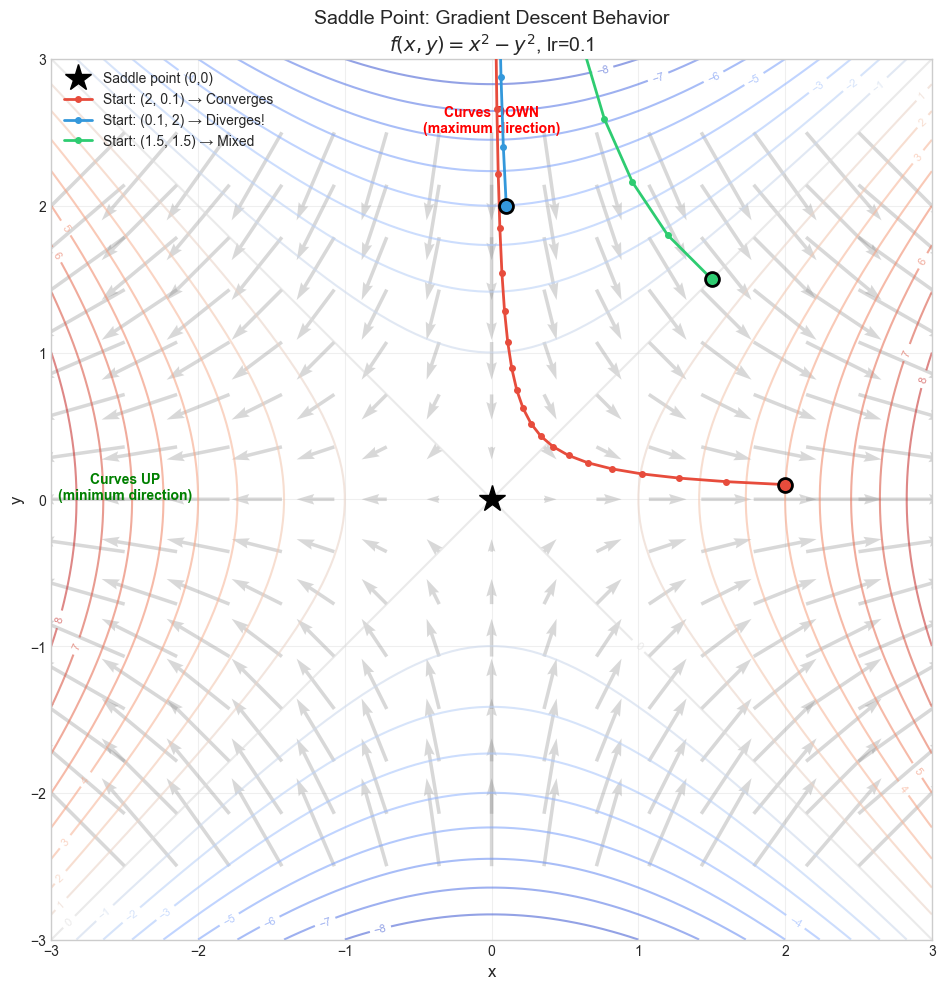


🔍 Saddle Point Analysis:
Function: f(x,y) = x² - y²
Hessian: [[2, 0], [0, -2]]
Eigenvalues: λ₁ = 2 (positive), λ₂ = -2 (negative)

📊 Gradient Descent Behavior:
   Start: (2, 0.1): Final distance from origin = 11.4475
   Start: (0.1, 2): Final distance from origin = 10.3196
   Start: (1.5, 1.5): Final distance from origin = 11.1459

💡 Insight: The direction of initial displacement determines convergence!
   → Along positive curvature: converges to saddle
   → Along negative curvature: diverges away

🎮 Try changing the learning rate or starting points to explore different behaviors!


In [8]:
# ============================================================
# Section 5: Saddle Point Animation
# ============================================================

def animate_saddle_optimization():
    def f(X, Y):
        return X**2 - Y**2
    def grad_f(x, y):
        return np.array([2*x, -2*y])
    def hessian_f(x, y):
        return np.array([[2, 0], [0, -2]])
    lr = 0.1
    n_steps = 50
    start_points = [
        np.array([2.0, 0.1]),
        np.array([0.1, 2.0]),
        np.array([1.5, 1.5])
    ]
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    labels = ['Start: (2, 0.1) → Converges', 'Start: (0.1, 2) → Diverges!', 'Start: (1.5, 1.5) → Mixed']
    fig, ax = plt.subplots(figsize=(12, 10))
    X, Y = create_surface_grid(n_points=100)
    Z = f(X, Y)
    contour = ax.contour(X, Y, Z, levels=20, cmap='coolwarm', alpha=0.6)
    ax.clabel(contour, inline=True, fontsize=8)
    x_grid = np.linspace(-2.5, 2.5, 15)
    y_grid = np.linspace(-2.5, 2.5, 15)
    Xg, Yg = np.meshgrid(x_grid, y_grid)
    U = 2*Xg
    V = -2*Yg
    ax.quiver(Xg, Yg, U, V, alpha=0.3, scale=50, color='gray')
    ax.plot(0, 0, 'k*', markersize=20, label='Saddle point (0,0)', zorder=5)
    trajectories = []
    for start, color, label in zip(start_points, colors, labels):
        traj = [start.copy()]
        pos = start.copy()
        for _ in range(n_steps):
            g = grad_f(pos[0], pos[1])
            pos = pos - lr * g
            traj.append(pos.copy())
            if np.linalg.norm(pos) > 10:
                break
        traj = np.array(traj)
        trajectories.append(traj)
        ax.plot(traj[:, 0], traj[:, 1], 'o-', color=color, markersize=4,
                linewidth=2, label=label, zorder=4)
        ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=10,
                markeredgecolor='black', markeredgewidth=2, zorder=5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title('Saddle Point: Gradient Descent Behavior\n$f(x,y) = x^2 - y^2$, lr=0.1', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.annotate('Curves UP\n(minimum direction)', xy=(-2.5, 0), fontsize=10,
                color='green', fontweight='bold', ha='center')
    ax.annotate('Curves DOWN\n(maximum direction)', xy=(0, 2.5), fontsize=10,
                color='red', fontweight='bold', ha='center')
    plt.tight_layout()
    plt.show()
    print("\n🔍 Saddle Point Analysis:")
    print("="*50)
    print("Function: f(x,y) = x² - y²")
    print("Hessian: [[2, 0], [0, -2]]")
    print("Eigenvalues: λ₁ = 2 (positive), λ₂ = -2 (negative)")
    print("\n📊 Gradient Descent Behavior:")
    for label, traj in zip(labels, trajectories):
        final_dist = np.linalg.norm(traj[-1])
        print(f"   {label.split('→')[0].strip()}: Final distance from origin = {final_dist:.4f}")
    print("\n💡 Insight: The direction of initial displacement determines convergence!")
    print("   → Along positive curvature: converges to saddle")
    print("   → Along negative curvature: diverges away")

animate_saddle_optimization()

print("\n🎮 Try changing the learning rate or starting points to explore different behaviors!")

---

# 6. Hessian Heatmap Visualization

## 🎯 Objective

Visualize the Hessian matrix as a heatmap with color-coded positive/negative values.

## 📖 Color Coding

- **Red/Positive**: Positive curvature (convex direction)
- **Blue/Negative**: Negative curvature (concave direction)
- **White/Zero**: Flat direction (no curvature)

## 🧠 Interpretation

The heatmap reveals the structure of curvature:
- **Diagonal dominance**: Curvature is aligned with coordinate axes.
- **Off-diagonal magnitude**: Strong parameter coupling.
- **Uniform color**: Isotropic curvature (same in all directions).

## 🤖 AI Relevance

In neural networks, Hessian heatmaps reveal:
- **Parameter coupling**: Which weights interact strongly.
- **Curvature anisotropy**: Whether some directions need larger/smaller updates.
- **Flat directions**: Directions where the loss doesn't change (redundant parameters).

In [9]:
# ============================================================
# Section 6: Hessian Heatmap
# ============================================================

def plot_hessian_heatmap(func_str='x**2 + y**2', x_point=0, y_point=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    H = np.array([
        [float(f_xx.subs([(x, x_point), (y, y_point)])),
         float(f_xy.subs([(x, x_point), (y, y_point)]))],
        [float(f_xy.subs([(x, x_point), (y, y_point)])),
         float(f_yy.subs([(x, x_point), (y, y_point)]))]
    ])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    X, Y = create_surface_grid(n_points=60)
    f_func = sp.lambdify((x, y), f, 'numpy')
    Z = f_func(X, Y)
    im1 = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax1.plot(x_point, y_point, 'r*', markersize=20, markeredgecolor='white',
             markeredgewidth=2, label='Evaluation point')
    ax1.set_title(f'Surface: $f(x,y) = {sp.latex(f)}$', fontsize=13)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_aspect('equal')
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    vmax = max(abs(H.flatten())) * 1.2
    im2 = ax2.imshow(H, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                     interpolation='nearest')
    labels = [['$f_{xx}$', '$f_{xy}$'], ['$f_{yx}$', '$f_{yy}$']]
    for i in range(2):
        for j in range(2):
            text_color = 'white' if abs(H[i, j]) > vmax * 0.5 else 'black'
            ax2.text(j, i, f'{H[i, j]:.3f}\n({labels[i][j]})',
                    ha='center', va='center', color=text_color,
                    fontsize=14, fontweight='bold')
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['$\partial x$', '$\partial y$'])
    ax2.set_yticklabels(['$\partial x$', '$\partial y$'])
    ax2.set_title(f'Hessian at ({x_point:.2f}, {y_point:.2f})', fontsize=13)
    plt.colorbar(im2, ax=ax2, shrink=0.8, label='Curvature magnitude')
    plt.suptitle('Hessian Matrix Heatmap', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    eigvals, eigvecs = np.linalg.eigh(H)
    print(f"\n📊 Hessian at ({x_point:.2f}, {y_point:.2f}):")
    print(H)
    print(f"\n🔍 Eigenvalues: {eigvals}")
    print(f"🔍 Eigenvectors:\n{eigvecs}")
    if all(eigvals > 0):
        classification = '✅ Positive Definite (Local Minimum)'
    elif all(eigvals < 0):
        classification = '✅ Negative Definite (Local Maximum)'
    elif np.any(eigvals > 0) and np.any(eigvals < 0):
        classification = '⚠️ Indefinite (Saddle Point)'
    elif all(eigvals >= 0) and np.any(eigvals == 0):
        classification = '⚠️ Positive Semi-Definite (Flat Minimum)'
    else:
        classification = '⚠️ Negative Semi-Definite (Flat Maximum)'
    print(f"\n📐 Classification: {classification}")

interact(
    plot_hessian_heatmap,
    func_str=Dropdown(
        options={
            'Paraboloid': 'x**2 + y**2',
            'Saddle': 'x**2 - y**2',
            'Gaussian': 'exp(-(x**2 + y**2)/2)',
            'Cubic': 'x**3 + y**3 - 3*x*y',
            'Rosenbrock': '(1-x)**2 + 100*(y-x**2)**2'
        },
        value='x**2 + y**2',
        description='Function:'
    ),
    x_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='x:'),
    y_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='y:')
)

print("\n🎮 Move the point to see how the Hessian changes across the surface!")

interactive(children=(Dropdown(description='Function:', options={'Paraboloid': 'x**2 + y**2', 'Saddle': 'x**2 …


🎮 Move the point to see how the Hessian changes across the surface!


---

# 7. Curvature Along Different Directions

## 🎯 Objective

Visualize how curvature changes when moving in different directions from a point.

## 📖 Mathematical Background

The **directional second derivative** in direction $\mathbf{u}$ (unit vector) is:

$$\
D^2_{\mathbf{u}} f = \mathbf{u}^T H \mathbf{u}\
$$

For a 2D direction $\mathbf{u} = (\cos \theta, \sin \theta)$:

$$\
D^2_{\mathbf{u}} f = f_{xx} \cos^2 \theta + 2f_{xy} \cos \theta \sin \theta + f_{yy} \sin^2 \theta\
$$

## 🧠 Intuition

The directional curvature forms a **polar plot** that reveals:
- **Maximum curvature**: Direction of steepest upward curve.
- **Minimum curvature**: Direction of steepest downward curve.
- **Zero crossings**: Directions where the surface is locally flat.

## 🤖 AI Relevance

In optimization, the **condition number** $\kappa = \lambda_{max} / \lambda_{min}$
measures how "stretched" the curvature is. High condition numbers mean
gradient descent zigzags inefficiently — a key motivation for preconditioning.

In [10]:
# ============================================================
# Section 7: Curvature Along Different Directions
# ============================================================

def plot_directional_curvature(func_str='x**2 - y**2', x_point=0, y_point=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = float(sp.diff(f, x, 2).subs([(x, x_point), (y, y_point)]))
    f_yy = float(sp.diff(f, y, 2).subs([(x, x_point), (y, y_point)]))
    f_xy = float(sp.diff(f, x, y).subs([(x, x_point), (y, y_point)]))
    H = np.array([[f_xx, f_xy], [f_xy, f_yy]])
    theta = np.linspace(0, 2*np.pi, 360)
    curvature = []
    for t in theta:
        u = np.array([np.cos(t), np.sin(t)])
        c = u.T @ H @ u
        curvature.append(c)
    curvature = np.array(curvature)
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection='polar')
    ax1.plot(theta, curvature, linewidth=2, color='#e74c3c')
    ax1.fill(theta, curvature, alpha=0.3, color='#e74c3c')
    ax1.set_title('Directional Curvature (Polar Plot)', fontsize=13, pad=20)
    ax1.set_xlabel('Direction \theta')
    ax2 = fig.add_subplot(122)
    ax2.plot(theta * 180 / np.pi, curvature, linewidth=2, color='#3498db')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Direction \theta (degrees)', fontsize=12)
    ax2.set_ylabel('Curvature $\mathbf{u}^T H \mathbf{u}$', fontsize=12)
    ax2.set_title('Directional Curvature vs Angle', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 360)
    plt.suptitle(f'Directional Curvature Analysis\n$f(x,y) = {sp.latex(f)}$ at $({x_point:.2f}, {y_point:.2f})$',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    eigvals, eigvecs = np.linalg.eigh(H)
    print(f"\n📊 Hessian at ({x_point:.2f}, {y_point:.2f}):")
    print(H)
    print(f"\n🔍 Eigenvalues: {eigvals}")
    print(f"🔍 Eigenvectors:\n{eigvecs}")
    print(f"\n📐 Maximum curvature: {max(eigvals):.4f} in direction {eigvecs[:, np.argmax(eigvals)]}")
    print(f"📐 Minimum curvature: {min(eigvals):.4f} in direction {eigvecs[:, np.argmin(eigvals)]}")
    print(f"📐 Condition number: {max(abs(eigvals))/max(min(abs(eigvals)), 1e-10):.4f}")

interact(
    plot_directional_curvature,
    func_str=Dropdown(
        options={
            'Paraboloid': 'x**2 + y**2',
            'Saddle': 'x**2 - y**2',
            'Gaussian': 'exp(-(x**2 + y**2)/2)',
            'Cubic': 'x**3 + y**3 - 3*x*y'
        },
        value='x**2 - y**2',
        description='Function:'
    ),
    x_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='x:'),
    y_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='y:')
)

print("\n🎮 Adjust the angle slider to see how curvature changes with direction!")

interactive(children=(Dropdown(description='Function:', index=1, options={'Paraboloid': 'x**2 + y**2', 'Saddle…


🎮 Adjust the angle slider to see how curvature changes with direction!


---

# 8. Taylor Approximation Visualization

## 🎯 Objective

Visualize the second-order Taylor approximation and compare its quality near and far from the expansion point.

## 📖 Mathematical Background

The **second-order Taylor expansion** of $f$ around $(x_0, y_0)$ is:

$$\
f(x, y) \approx f(x_0, y_0) + \nabla f(x_0, y_0)^T \begin{bmatrix} x-x_0 \\ y-y_0 \end{bmatrix} + \frac{1}{2} \begin{bmatrix} x-x_0 & y-y_0 \end{bmatrix} H \begin{bmatrix} x-x_0 \\ y-y_0 \end{bmatrix}\
$$

## 🧠 Intuition

- **Near** the expansion point: The approximation is excellent (Hessian captures local curvature).
- **Far** from the expansion point: Higher-order terms dominate, approximation breaks down.

## 🤖 AI Relevance

In optimization, Newton's method uses the second-order Taylor approximation to
find the minimum of a local quadratic model. The quality of this approximation
determines convergence speed.

In [11]:
# ============================================================
# Section 8: Taylor Approximation Visualization
# ============================================================

def taylor_approximation(func_str='x**2 + y**2', x0=0, y0=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_x = sp.diff(f, x)
    f_y = sp.diff(f, y)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f0 = float(f.subs([(x, x0), (y, y0)]))
    fx0 = float(f_x.subs([(x, x0), (y, y0)]))
    fy0 = float(f_y.subs([(x, x0), (y, y0)]))
    fxx0 = float(f_xx.subs([(x, x0), (y, y0)]))
    fyy0 = float(f_yy.subs([(x, x0), (y, y0)]))
    fxy0 = float(f_xy.subs([(x, x0), (y, y0)]))
    X, Y = create_surface_grid(n_points=80)
    f_func = sp.lambdify((x, y), f, 'numpy')
    Z_true = f_func(X, Y)
    dx = X - x0
    dy = Y - y0
    Z_taylor = f0 + fx0*dx + fy0*dy + 0.5*(fxx0*dx**2 + 2*fxy0*dx*dy + fyy0*dy**2)
    error = np.abs(Z_true - Z_taylor)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    im1 = axes[0, 0].contourf(X, Y, Z_true, levels=20, cmap='viridis')
    axes[0, 0].plot(x0, y0, 'r*', markersize=15, label='Expansion point')
    axes[0, 0].set_title('Original Function', fontsize=13)
    axes[0, 0].legend()
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)
    im2 = axes[0, 1].contourf(X, Y, Z_taylor, levels=20, cmap='viridis')
    axes[0, 1].plot(x0, y0, 'r*', markersize=15, label='Expansion point')
    axes[0, 1].set_title('2nd-Order Taylor Approximation', fontsize=13)
    axes[0, 1].legend()
    plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)
    im3 = axes[1, 0].contourf(X, Y, error, levels=20, cmap='hot')
    axes[1, 0].plot(x0, y0, 'w*', markersize=15, label='Expansion point')
    axes[1, 0].set_title('Approximation Error |f - Taylor|', fontsize=13)
    axes[1, 0].legend()
    plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)
    axes[1, 1].hist(error.flatten(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Error Distribution', fontsize=13)
    axes[1, 1].set_xlabel('Absolute Error')
    axes[1, 1].set_ylabel('Frequency')
    plt.suptitle(f'Taylor Approximation: $f(x,y) = {sp.latex(f)}$ at $({x0:.2f}, {y0:.2f})$',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    max_error = np.max(error)
    mean_error = np.mean(error)
    print(f"\n📊 Approximation Quality at ({x0:.2f}, {y0:.2f}):")
    print(f"   Maximum error: {max_error:.4f}")
    print(f"   Mean error: {mean_error:.4f}")
    print(f"   Taylor expansion: f ≈ {f0:.4f} + {fx0:.4f}(x-{x0}) + {fy0:.4f}(y-{y0}) + 0.5*[{fxx0:.4f}(x-{x0})² + {2*fxy0:.4f}(x-{x0})(y-{y0}) + {fyy0:.4f}(y-{y0})²]")

interact(
    taylor_approximation,
    func_str=Dropdown(
        options={
            'Paraboloid': 'x**2 + y**2',
            'Saddle': 'x**2 - y**2',
            'Gaussian': 'exp(-(x**2 + y**2)/2)',
            'Cubic': 'x**3 + y**3 - 3*x*y'
        },
        value='x**2 + y**2',
        description='Function:'
    ),
    x0=FloatSlider(min=-2, max=2, step=0.1, value=0, description='x0:'),
    y0=FloatSlider(min=-2, max=2, step=0.1, value=0, description='y0:')
)

print("\n🎮 Move the expansion point to see how approximation quality changes!")

interactive(children=(Dropdown(description='Function:', options={'Paraboloid': 'x**2 + y**2', 'Saddle': 'x**2 …


🎮 Move the expansion point to see how approximation quality changes!


---

# 9. Newton's Method Animation

## 🎯 Objective

Visualize Newton's optimization method and display the current point, gradient, Hessian, and next iteration.

## 📖 Mathematical Background

Newton's update rule:

$$\
\mathbf{x}_{n+1} = \mathbf{x}_n - H^{-1} \nabla f(\mathbf{x}_n)\
$$

This uses curvature information (Hessian) to take more direct steps toward the minimum.

## 🧠 Intuition

- Gradient descent: "go downhill" (ignores curvature)
- Newton's method: "go to the bottom of the parabola" (uses curvature)

## 🤖 AI Relevance

Newton's method converges in fewer iterations but requires computing and inverting
the Hessian — expensive for high-dimensional neural networks. Variants like L-BFGS
approximate the Hessian to balance cost and convergence speed.

In [12]:
# ============================================================
# Section 9: Newton's Method Animation
# ============================================================

def newtons_method_visualization(func_str='x**2 + y**2', x0=2.0, y0=2.0, lr=1.0, n_iter=5):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_x = sp.diff(f, x)
    f_y = sp.diff(f, y)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_func = sp.lambdify((x, y), f, 'numpy')
    X, Y = create_surface_grid(n_points=80)
    Z = f_func(X, Y)
    pos = np.array([x0, y0])
    trajectory = [pos.copy()]
    hessians = []
    gradients = []
    for _ in range(n_iter):
        fx_val = float(f_x.subs([(x, pos[0]), (y, pos[1])]))
        fy_val = float(f_y.subs([(x, pos[0]), (y, pos[1])]))
        grad = np.array([fx_val, fy_val])
        fxx_val = float(f_xx.subs([(x, pos[0]), (y, pos[1])]))
        fyy_val = float(f_yy.subs([(x, pos[0]), (y, pos[1])]))
        fxy_val = float(f_xy.subs([(x, pos[0]), (y, pos[1])]))
        H = np.array([[fxx_val, fxy_val], [fxy_val, fyy_val]])
        try:
            H_inv = np.linalg.inv(H)
            step = -H_inv @ grad
        except:
            step = -grad
        pos = pos + lr * step
        trajectory.append(pos.copy())
        gradients.append(grad)
        hessians.append(H)
    trajectory = np.array(trajectory)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    im1 = axes[0].contourf(X, Y, Z, levels=20, cmap='viridis')
    axes[0].plot(trajectory[:, 0], trajectory[:, 1], 'r-o', markersize=8,
                 linewidth=2, label='Newton path', zorder=5)
    axes[0].plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=15,
                 label='Start', zorder=6)
    axes[0].plot(trajectory[-1, 0], trajectory[-1, 1], 'b*', markersize=20,
                 label='End', zorder=6)
    for i, (x_p, y_p) in enumerate(trajectory[:-1]):
        axes[0].annotate(f'{i}', (x_p, y_p), textcoords="offset points",
                         xytext=(5, 5), fontsize=10, color='white', fontweight='bold')
    axes[0].set_title("Newton's Method Trajectory", fontsize=14)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend()
    axes[0].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0], shrink=0.8)
    axes[1].axis('off')
    info_text = f"Newton's Method: $f(x,y) = {sp.latex(f)}$\n\n"
    for i in range(len(gradients)):
        info_text += f"Iteration {i+1}:\n"
        info_text += f"  Point: ({trajectory[i,0]:.3f}, {trajectory[i,1]:.3f})\n"
        info_text += f"  Gradient: [{gradients[i][0]:.3f}, {gradients[i][1]:.3f}]\n"
        info_text += f"  Hessian: [[{hessians[i][0,0]:.3f}, {hessians[i][0,1]:.3f}], [{hessians[i][1,0]:.3f}, {hessians[i][1,1]:.3f}]]\n\n"
    info_text += f"Final: ({trajectory[-1,0]:.3f}, {trajectory[-1,1]:.3f})\n"
    axes[1].text(0.1, 0.5, info_text, transform=axes[1].transAxes,
                 fontsize=11, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    plt.suptitle(f"Newton's Method Visualization\nLearning Rate = {lr}", fontsize=16)
    plt.tight_layout()
    plt.show()
    print(f"\n✅ Converged to ({trajectory[-1,0]:.4f}, {trajectory[-1,1]:.4f}) in {len(gradients)} iterations")

interact(
    newtons_method_visualization,
    func_str=Dropdown(
        options={
            'Paraboloid': 'x**2 + y**2',
            'Saddle': 'x**2 - y**2',
            'Rosenbrock': '(1-x)**2 + 100*(y-x**2)**2'
        },
        value='x**2 + y**2',
        description='Function:'
    ),
    x0=FloatSlider(min=-3, max=3, step=0.1, value=2, description='x0:'),
    y0=FloatSlider(min=-3, max=3, step=0.1, value=2, description='y0:'),
    lr=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='LR:'),
    n_iter=IntSlider(min=1, max=10, step=1, value=5, description='Iterations:')
)

print("\n🎮 Adjust learning rate and starting point to explore Newton's method!")

interactive(children=(Dropdown(description='Function:', options={'Paraboloid': 'x**2 + y**2', 'Saddle': 'x**2 …


🎮 Adjust learning rate and starting point to explore Newton's method!


---

# 10. Optimization Landscape

## 🎯 Objective

Create interactive loss landscapes and animate optimization trajectories.

## 📖 Examples

| Landscape | Characteristics | Optimization Challenge |
|-----------|-----------------|------------------------|
| **Convex Bowl** | Single global minimum | Easy — any method works |
| **Saddle Surface** | Zero gradient, mixed curvature | Hard — first-order methods struggle |
| **Non-Convex** | Multiple local minima | Very hard — can get stuck |

## 🤖 AI Relevance

Neural network loss landscapes are typically non-convex with many saddles.
Understanding landscape geometry helps explain why SGD with momentum often
outperforms plain gradient descent — momentum helps escape saddles and shallow valleys.

In [ ]:
# ============================================================
# Section 10: Optimization Landscape
# ============================================================

def optimization_landscape(landscape='Convex Bowl', method='Gradient Descent',
                            lr=0.1, n_iter=50, x0=2.0, y0=2.0):
    if landscape == 'Convex Bowl':
        def f(X, Y):
            return X**2 + Y**2
        def grad_f(x, y):
            return np.array([2*x, 2*y])
    elif landscape == 'Saddle Surface':
        def f(X, Y):
            return X**2 - Y**2
        def grad_f(x, y):
            return np.array([2*x, -2*y])
    elif landscape == 'Non-Convex (Rosenbrock)':
        def f(X, Y):
            return (1-X)**2 + 100*(Y-X**2)**2
        def grad_f(x, y):
            return np.array([-2*(1-x) - 400*x*(y-x**2), 200*(y-x**2)])
    elif landscape == 'Non-Convex (Himmelblau)':
        def f(X, Y):
            return (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2
        def grad_f(x, y):
            return np.array([4*x*(x**2+y-11) + 2*(x+y**2-7),
                             2*(x**2+y-11) + 4*y*(x+y**2-7)])
    pos = np.array([x0, y0])
    traj = [pos.copy()]
    for _ in range(n_iter):
        g = grad_f(pos[0], pos[1])
        if method == 'Gradient Descent':
            pos = pos - lr * g
        elif method == 'Newton':
            if landscape == 'Convex Bowl':
                H = np.array([[2, 0], [0, 2]])
            elif landscape == 'Saddle Surface':
                H = np.array([[2, 0], [0, -2]])
            else:
                pos = pos - lr * g
                traj.append(pos.copy())
                continue
            try:
                pos = pos - lr * np.linalg.inv(H) @ g
            except:
                pos = pos - lr * g
        traj.append(pos.copy())
    traj = np.array(traj)
    if landscape == 'Convex Bowl':
        X, Y = create_surface_grid((-3, 3), (-3, 3), 80)
    elif landscape == 'Saddle Surface':
        X, Y = create_surface_grid((-3, 3), (-3, 3), 80)
    elif landscape == 'Non-Convex (Rosenbrock)':
        X, Y = create_surface_grid((-2, 2), (-1, 3), 80)
    else:
        X, Y = create_surface_grid((-5, 5), (-5, 5), 80)
    Z = f(X, Y)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
    ax.plot(traj[:, 0], traj[:, 1], 'r-o', markersize=5, linewidth=2,
            label=f'{method} path', zorder=5)
    ax.plot(traj[0, 0], traj[0, 1], 'go', markersize=12, label='Start', zorder=6)
    ax.plot(traj[-1, 0], traj[-1, 1], 'b*', markersize=15, label='End', zorder=6)
    ax.set_title(f'{landscape} — {method} Optimization\nLR={lr}, {n_iter} iterations', fontsize=14)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
    print(f"\n📊 Final position: ({traj[-1,0]:.4f}, {traj[-1,1]:.4f})")
    print(f"📊 Final function value: {f(traj[-1,0], traj[-1,1]):.6f}")

interact(
    optimization_landscape,
    landscape=Dropdown(
        options=['Convex Bowl', 'Saddle Surface', 'Non-Convex (Rosenbrock)', 'Non-Convex (Himmelblau)'],
        value='Convex Bowl',
        description='Landscape:'
    ),
    method=Dropdown(
        options=['Gradient Descent', 'Newton'],
        value='Gradient Descent',
        description='Method:'
    ),
    lr=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1, description='LR:'),
    n_iter=IntSlider(min=10, max=200, step=10, value=50, description='Iterations:'),
    x0=FloatSlider(min=-3, max=3, step=0.1, value=2, description='x0:'),
    y0=FloatSlider(min=-3, max=3, step=0.1, value=2, description='y0:')
)

print("\n🎮 Explore different landscapes and optimization methods!")

interactive(children=(Dropdown(description='Landscape:', options=('Convex Bowl', 'Saddle Surface', 'Non-Convex…


🎮 Explore different landscapes and optimization methods!


---

# 2. Second Derivative Explorer

## Objective

Visualize the three second-order partial derivatives that form the Hessian matrix.

## Mathematical Background

For a function $f(x, y)$, the second-order partial derivatives are:

$$\
f_{xx} = \frac{\partial^2 f}{\partial x^2}, \quad
f_{yy} = \frac{\partial^2 f}{\partial y^2}, \quad
f_{xy} = \frac{\partial^2 f}{\partial x \partial y} = f_{yx}\
$$

## Intuition

- **$f_{xx}$**: How does the slope in the $x$-direction change as we move in $x$?
- **$f_{yy}$**: How does the slope in the $y$-direction change as we move in $y$?
- **$f_{xy}$**: How does the slope in the $x$-direction change as we move in $y$? (cross-curvature)

These three values completely determine the local curvature at any point.

## AI Relevance

In neural networks, the diagonal entries ($f_{xx}$, $f_{yy}$) relate to the
**curvature along each parameter dimension**, while the off-diagonal entries
($f_{xy}$) capture **parameter interactions** — how changing one weight affects
the gradient with respect to another.

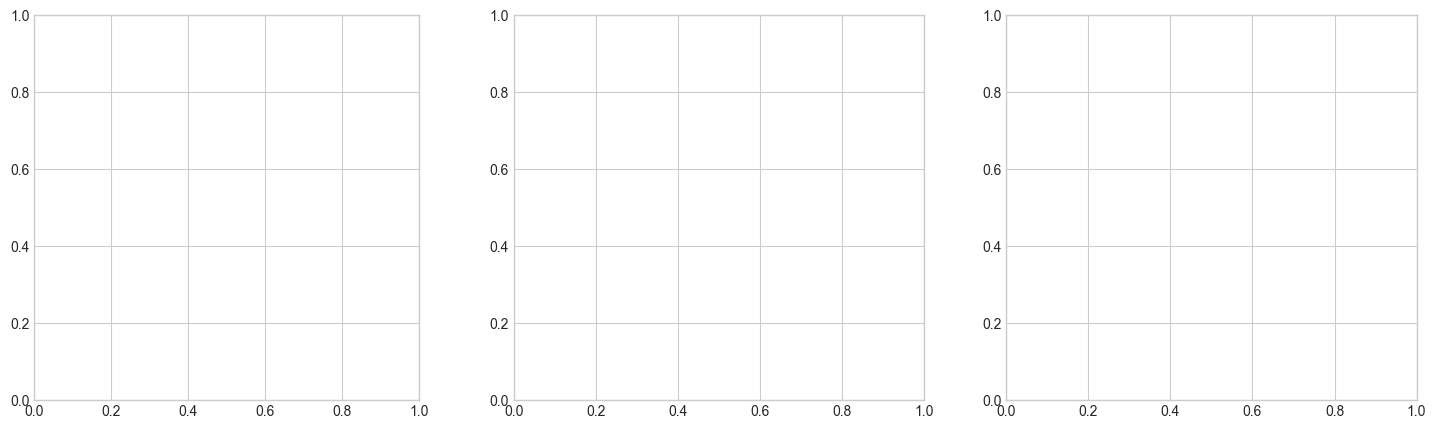

interactive(children=(Dropdown(description='Function:', options={'Paraboloid': 'x**2 + y**2', 'Saddle': 'x**2 …


Select a function and move the point to see how second derivatives change!


In [14]:
# ============================================================
# Section 2: Second Derivative Explorer
# ============================================================

def compute_second_derivatives_symbolic(func_str, x_val=0, y_val=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_xx_val = float(f_xx.subs([(x, x_val), (y, y_val)]))
    f_yy_val = float(f_yy.subs([(x, x_val), (y, y_val)]))
    f_xy_val = float(f_xy.subs([(x, x_val), (y, y_val)]))
    return {
        'f_xx': f_xx, 'f_yy': f_yy, 'f_xy': f_xy,
        'f_xx_val': f_xx_val, 'f_yy_val': f_yy_val, 'f_xy_val': f_xy_val,
        'hessian': np.array([[f_xx_val, f_xy_val], [f_xy_val, f_yy_val]])
    }

def plot_second_derivatives(func_str='x**2 + y**2', x_point=0.0, y_point=0.0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_xx_func = sp.lambdify((x, y), f_xx, 'numpy')
    f_yy_func = sp.lambdify((x, y), f_yy, 'numpy')
    f_xy_func = sp.lambdify((x, y), f_xy, 'numpy')
    X, Y = create_surface_grid(n_points=80)
    Z_xx = f_xx_func(X, Y)
    Z_yy = f_yy_func(X, Y)
    Z_xy = f_xy_func(X, Y)
    Z_xx = np.array(Z_xx)
    Z_yy = np.array(Z_yy)
    Z_xy = np.array(Z_xy)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = [
        f'$f_{{xx}} = {sp.latex(f_xx)}$',
        f'$f_{{yy}} = {sp.latex(f_yy)}$',
        f'$f_{{xy}} = {sp.latex(f_xy)}$'
    ]
    data_list = [Z_xx, Z_yy, Z_xy]
    for ax, data, title in zip(axes, data_list, titles):
        im = ax.imshow(data, extent=[-3, 3, -3, 3], origin='lower',
                       cmap='RdBu_r', aspect='equal')
        ax.plot(x_point, y_point, 'ko', markersize=12, markeredgecolor='white',
                markeredgewidth=2, label='Selected point')
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(loc='upper right')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.suptitle(f'Second-Order Partial Derivatives\n$f(x,y) = {sp.latex(f)}$ at $({x_point:.2f}, {y_point:.2f})$',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    f_xx_val = float(f_xx.subs([(x, x_point), (y, y_point)]))
    f_yy_val = float(f_yy.subs([(x, x_point), (y, y_point)]))
    f_xy_val = float(f_xy.subs([(x, x_point), (y, y_point)]))
    print(f"\nValues at ({x_point:.2f}, {y_point:.2f}):")
    print(f"   f_xx = {f_xx_val:.4f}")
    print(f"   f_yy = {f_yy_val:.4f}")
    print(f"   f_xy = {f_xy_val:.4f}")
    print(f"\nHessian at this point:")
    H = np.array([[f_xx_val, f_xy_val], [f_xy_val, f_yy_val]])
    print(H)

function_options = {
    'Paraboloid': 'x**2 + y**2',
    'Saddle': 'x**2 - y**2',
    'Gaussian': 'exp(-(x**2 + y**2)/2)',
    'Cubic': 'x**3 + y**3 - 3*x*y',
    'Rosenbrock': '(1-x)**2 + 100*(y-x**2)**2'
}

interact(
    plot_second_derivatives,
    func_str=Dropdown(options=function_options, value='x**2 + y**2', description='Function:'),
    x_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='x:'),
    y_point=FloatSlider(min=-2, max=2, step=0.1, value=0, description='y:')
)

print("\nSelect a function and move the point to see how second derivatives change!")

---

# 3. Hessian Matrix Construction Animation

## Objective

Animate the step-by-step construction of the Hessian matrix to emphasize
its symmetry and the meaning of each entry.

## Mathematical Background

The Hessian is built from second-order partial derivatives:

$$\
H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}\
$$

## Key Insight: Symmetry

By **Clairaut's Theorem**, if the second partial derivatives are continuous, then:

$$\
\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}\
$$

This means the Hessian is always a **symmetric matrix**, which guarantees
real eigenvalues — a crucial property for optimization analysis.

## AI Relevance

The symmetry of the Hessian means we only need to compute $n(n+1)/2$ entries
instead of $n^2$, significantly reducing computational cost in high-dimensional
neural network optimization.

In [ ]:
# ============================================================
# Section 3: Hessian Matrix Construction Animation
# ============================================================

def animate_hessian_construction(func_str='x**2 + y**2', x_point=0, y_point=0):
    x, y = sp.symbols('x y', real=True)
    f = sp.sympify(func_str)
    f_x = sp.diff(f, x)
    f_y = sp.diff(f, y)
    f_xx = sp.diff(f, x, 2)
    f_yy = sp.diff(f, y, 2)
    f_xy = sp.diff(f, x, y)
    f_yx = sp.diff(f, y, x)
    vals = {
        'f_xx': float(f_xx.subs([(x, x_point), (y, y_point)])),
        'f_yy': float(f_yy.subs([(x, x_point), (y, y_point)])),
        'f_xy': float(f_xy.subs([(x, x_point), (y, y_point)])),
        'f_yx': float(f_yx.subs([(x, x_point), (y, y_point)]))
    }
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Hessian Matrix Construction: $f(x,y) = {sp.latex(f)}$ at $({x_point}, {y_point})$',
                 fontsize=16, y=0.98)
    ax = axes[0, 0]
    X, Y = create_surface_grid(n_points=50)
    f_func = sp.lambdify((x, y), f, 'numpy')
    Z = f_func(X, Y)
    ax.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax.plot(x_point, y_point, 'r*', markersize=20, label='Expansion point')
    ax.set_title('Step 1: Original Function', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.set_aspect('equal')
    ax = axes[0, 1]
    ax.text(0.5, 0.7, r'$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$',
            ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.text(0.5, 0.4, f'$f_x = {sp.latex(f_x)}$\n$f_y = {sp.latex(f_y)}$',
            ha='center', va='center', fontsize=14, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('Step 2: Compute Gradient', fontsize=13)
    ax.axis('off')
    ax = axes[1, 0]
    ax.text(0.5, 0.8, 'Second-Order Partial Derivatives:',
            ha='center', va='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.55, f'$f_{{xx}} = {sp.latex(f_xx)} = {vals["f_xx"]:.2f}$\n\n
            f'$f_{{yy}} = {sp.latex(f_yy)} = {vals["f_yy"]:.2f}$\n\n
            f'$f_{{xy}} = {sp.latex(f_xy)} = {vals["f_xy"]:.2f}$\n\n
            f'$f_{{yx}} = {sp.latex(f_yx)} = {vals["f_yx"]:.2f}$',
            ha='center', va='center', fontsize=13, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    ax.text(0.5, 0.15, f'Symmetry check: $f_{{xy}} = f_{{yx}}$ ({vals["f_xy"]:.2f} = {vals["f_yx"]:.2f})',
            ha='center', va='center', fontsize=12, color='green', fontweight='bold', transform=ax.transAxes)
    ax.set_title('Step 3: Compute Second Derivatives', fontsize=13)
    ax.axis('off')
    ax = axes[1, 1]
    H = np.array([[vals['f_xx'], vals['f_xy']], [vals['f_yx'], vals['f_yy']]])
    im = ax.imshow(H, cmap='RdBu_r', vmin=-max(abs(H.flatten()))-0.5,
                   vmax=max(abs(H.flatten()))+0.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['$\partial x$', '$\partial y$'])
    ax.set_yticklabels(['$\partial x$', '$\partial y$'])
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{H[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=18, fontweight='bold')
    ax.set_title('Step 4: Assemble Hessian Matrix', fontsize=13)
    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print(f"\nHessian Matrix at ({x_point}, {y_point}):")
    print(H)
    print(f"\nDeterminant: {np.linalg.det(H):.4f}")
    print(f"Trace: {np.trace(H):.4f}")

animate_hessian_construction('x**2 + y**2', 0, 0)

print("\nTry changing the function and point to see different Hessians!")

---

# 4. Convex vs Concave vs Saddle Surfaces

## Objective

Compare three fundamental surface types side-by-side and connect them to
Hessian definiteness.

## Mathematical Classification

The **definiteness** of the Hessian determines the local geometry:

| Type | Condition | Geometry | Example |
|------|-----------|----------|---------|
| **Positive Definite** | All eigenvalues $> 0$ | Convex (bowl) | $z = x^2 + y^2$ |
| **Negative Definite** | All eigenvalues $< 0$ | Concave (dome) | $z = -x^2 - y^2$ |
| **Indefinite** | Mixed signs | Saddle | $z = x^2 - y^2$ |
| **Positive Semi-Definite** | All $\geq 0$, some $= 0$ | Flat valley | $z = x^2$ |

## Intuition

- **Convex**: Water poured on the surface collects at the bottom.
- **Concave**: Water poured on the surface runs off the edges.
- **Saddle**: Water flows away in some directions, collects in others.

## AI Relevance

In deep learning:
- **Convex** loss -> guaranteed global minimum (rare).
- **Saddle points** -> common cause of slow training (gradients vanish).
- **Flat regions** -> can trap optimizers (Hessian near zero).

In [ ]:
# ============================================================
# Section 4: Convex vs Concave vs Saddle
# ============================================================

def compare_surfaces():
    X, Y = create_surface_grid(n_points=60)
    surfaces = {
        'Convex (Positive Definite)': {
            'Z': X**2 + Y**2,
            'equation': 'z = x^2 + y^2',
            'color': 'viridis',
            'hessian': '[[2, 0], [0, 2]]',
            'eigenvalues': 'λ₁ = 2, λ₂ = 2'
        },
        'Concave (Negative Definite)': {
            'Z': -(X**2 + Y**2),
            'equation': 'z = -(x^2 + y^2)',
            'color': 'plasma',
            'hessian': '[[-2, 0], [0, -2]]',
            'eigenvalues': 'λ₁ = -2, λ₂ = -2'
        },
        'Saddle (Indefinite)': {
            'Z': X**2 - Y**2,
            'equation': 'z = x^2 - y^2',
            'color': 'coolwarm',
            'hessian': '[[2, 0], [0, -2]]',
            'eigenvalues': 'λ₁ = 2, λ₂ = -2'
        }
    }
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=list(surfaces.keys())
    )
    for i, (name, data) in enumerate(surfaces.items()):
        fig.add_trace(
            go.Surface(
                x=X, y=Y, z=data['Z'],
                colorscale=data['color'],
                showscale=False,
                name=name
            ),
            row=1, col=i+1
        )
    fig.update_layout(
        title=dict(
            text='<b>Convex vs Concave vs Saddle</b><br><sub>Hessian Definiteness Determines Geometry</sub>',
            x=0.5, font=dict(size=18)
        ),
        height=500,
        width=1200
    )
    for i in range(1, 4):
        fig.update_scenes(
            aspectratio=dict(x=1, y=1, z=0.5),
            row=1, col=i
        )
    fig.show()
    print("\nComparison Table:")
    print("="*70)
    print(f"{'Type':<30} {'Equation':<25} {'Hessian':<20} {'Eigenvalues':<20}")
    print("="*70)
    for name, data in surfaces.items():
        print(f"{name:<30} {data['equation']:<25} {data['hessian']:<20} {data['eigenvalues']:<20}")
    print("="*70)

compare_surfaces()

print("\nKey Takeaway: The signs of the Hessian eigenvalues completely determine the local geometry.")

---

# 5. Saddle Point Animation

## Objective

Animate optimization around a saddle point to demonstrate why saddle points
are challenging for gradient-based optimization.

## Mathematical Background

At a saddle point $(x^*, y^*)$:
- $\nabla f(x^*, y^*) = 0$ (critical point)
- Hessian has both positive and negative eigenvalues
- The surface curves **up** in some directions and **down** in others

## Why Saddle Points Are Problematic

1. **Gradient is zero**: First-order methods stop (or slow dramatically).
2. **Curvature is misleading**: Some directions look like minima, others like maxima.
3. **High-dimensional saddles**: In $n$ dimensions, the probability of all eigenvalues
   having the same sign is exponentially small - saddles dominate!

## AI Relevance

Recent research (Dauphin et al., 2014) showed that in high-dimensional loss landscapes,
saddle points are far more common than local minima. Second-order methods (using Hessian)
can escape saddles by following negative curvature directions.

In [ ]:
# ============================================================
# Section 5: Saddle Point Animation
# ============================================================

def animate_saddle_optimization():
    def f(X, Y):
        return X**2 - Y**2
    def grad_f(x, y):
        return np.array([2*x, -2*y])
    def hessian_f(x, y):
        return np.array([[2, 0], [0, -2]])
    lr = 0.1
    n_steps = 50
    start_points = [
        np.array([2.0, 0.1]),
        np.array([0.1, 2.0]),
        np.array([1.5, 1.5])
    ]
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    labels = ['Start: (2, 0.1) -> Converges', 'Start: (0.1, 2) -> Diverges!', 'Start: (1.5, 1.5) -> Mixed']
    fig, ax = plt.subplots(figsize=(12, 10))
    X, Y = create_surface_grid(n_points=100)
    Z = f(X, Y)
    contour = ax.contour(X, Y, Z, levels=20, cmap='coolwarm', alpha=0.6)
    ax.clabel(contour, inline=True, fontsize=8)
    x_grid = np.linspace(-2.5, 2.5, 15)
    y_grid = np.linspace(-2.5, 2.5, 15)
    Xg, Yg = np.meshgrid(x_grid, y_grid)
    U = 2*Xg
    V = -2*Yg
    ax.quiver(Xg, Yg, U, V, alpha=0.3, scale=50, color='gray')
    ax.plot(0, 0, 'k*', markersize=20, label='Saddle point (0,0)', zorder=5)
    trajectories = []
    for start, color, label in zip(start_points, colors, labels):
        traj = [start.copy()]
        pos = start.copy()
        for _ in range(n_steps):
            g = grad_f(pos[0], pos[1])
            pos = pos - lr * g
            traj.append(pos.copy())
            if np.linalg.norm(pos) > 10:
                break
        traj = np.array(traj)
        trajectories.append(traj)
        ax.plot(traj[:, 0], traj[:, 1], 'o-', color=color, markersize=4,
                linewidth=2, label=label, zorder=4)
        ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=10,
                markeredgecolor='black', markeredgewidth=2, zorder=5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title('Saddle Point: Gradient Descent Behavior\n$f(x,y) = x^2 - y^2$, lr=0.1', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.annotate('Curves UP\n(minimum direction)', xy=(-2.5, 0), fontsize=10,
                color='green', fontweight='bold', ha='center')
    ax.annotate('Curves DOWN\n(maximum direction)', xy=(0, 2.5), fontsize=10,
                color='red', fontweight='bold', ha='center')
    plt.tight_layout()
    plt.show()
    print("\nSaddle Point Analysis:")
    print("="*50)
    print("Function: f(x,y) = x² - y²")
    print("Hessian: [[2, 0], [0, -2]]")
    print("Eigenvalues: λ₁ = 2 (positive), λ₂ = -2 (negative)")
    print("\nGradient Descent Behavior:")
    for label, traj in zip(labels, trajectories):
        final_dist = np.linalg.norm(traj[-1])
        print(f"   {label.split('->')[0].strip()}: Final distance from origin = {final_dist:.4f}")
    print("\nInsight: The direction of initial displacement determines convergence!")
    print("   -> Along positive curvature: converges to saddle")
    print("   -> Along negative curvature: diverges away")

animate_saddle_optimization()

print("\nTry changing the learning rate or starting points to explore different behaviors!")